In [3]:
import sys
!{sys.executable} -m pip install -q pandas numpy matplotlib seaborn scikit-learn nltk

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
import nltk

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("NLTK data downloaded successfully.")

NLTK data downloaded successfully.


In [22]:
import random
import pandas as pd

positive_starts = [
    "This product", "The item", "This phone", "The laptop", "The headphones",
    "This charger", "The bag", "The shoes", "This watch", "The camera",
    "The speaker", "The keyboard", "The mouse", "The bottle", "The blender"
]

positive_middle = [
    "is amazing", "works perfectly", "has excellent quality", "is worth every penny",
    "looks beautiful", "is very comfortable", "performs really well",
    "is outstanding", "is fantastic", "is impressive",
    "is reliable", "is easy to use", "is well designed",
    "is durable", "is exactly what I expected"
]

positive_end = [
    "I highly recommend it.",
    "I will definitely buy it again.",
    "Very happy with my purchase.",
    "Five stars from me.",
    "Excellent value for money.",
    "Delivery was fast.",
    "Customer service was excellent.",
    "I really loved it.",
    "Best purchase this year.",
    "Totally satisfied."
]

negative_starts = [
    "This product", "The item", "This phone", "The laptop", "The headphones",
    "This charger", "The bag", "The shoes", "This watch", "The camera",
    "The speaker", "The keyboard", "The mouse", "The bottle", "The blender"
]

negative_middle = [
    "is terrible", "has poor quality", "stopped working", "is not worth the money",
    "is disappointing", "is badly designed", "does not work properly",
    "is very slow", "is frustrating", "is unreliable",
    "is defective", "is useless", "is extremely disappointing",
    "is a waste of money", "is damaged"
]

negative_end = [
    "I do not recommend it.",
    "Very disappointed.",
    "One of my worst purchases.",
    "Customer service was terrible.",
    "Delivery was very late.",
    "I want a refund.",
    "Complete waste of money.",
    "Never buying again.",
    "Very poor experience.",
    "One star."
]

reviews = []
sentiments = []

used_reviews = set()

while len(reviews) < 500:
    review = f"{random.choice(positive_starts)} {random.choice(positive_middle)}. {random.choice(positive_end)}"
    if review not in used_reviews:
        reviews.append(review)
        sentiments.append("Positive")
        used_reviews.add(review)

while len(reviews) < 1000:
    review = f"{random.choice(negative_starts)} {random.choice(negative_middle)}. {random.choice(negative_end)}"
    if review not in used_reviews:
        reviews.append(review)
        sentiments.append("Negative")
        used_reviews.add(review)

df = pd.DataFrame({
    "Review": reviews,
    "Sentiment": sentiments
})

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.to_csv("sentiment_dataset.csv", index=False)

print("Dataset created successfully!")
print("Total Reviews:", len(df))
print(df.head())

Dataset created successfully!
Total Reviews: 1000
                                              Review Sentiment
0   The laptop is defective. Delivery was very late.  Negative
1      The shoes is frustrating. Never buying again.  Negative
2  The item does not work properly. Complete wast...  Negative
3  The headphones stopped working. Very poor expe...  Negative
4  The mouse is worth every penny. Best purchase ...  Positive


In [34]:
import pandas as pd

df = pd.read_csv("IMDB_Dataset_CLEANED.csv")

print(df.head())
print(df.columns)

                                              review sentiment
0  $25,000 Pyramid Clues: Deep Blue Sea. Tremors....  negative
1  0.5/10. This movie has absolutely nothing good...  negative
2  0*'s Christian Slater, Tara Reid, Stephen Dorf...  negative
3  102 Dalmatians (2000, Dir. Kevin Lima) <br /><...  negative
4  102 DALMATIANS [Walt Disney]: I wasn't a fan o...  negative
Index(['review', 'sentiment'], dtype='str')


In [38]:
print(df.info())

print("\nShape of Dataset:")
print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 49396 entries, 0 to 49395
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     49396 non-null  str  
 1   sentiment  49396 non-null  str  
dtypes: str(2)
memory usage: 771.9 KB
None

Shape of Dataset:
(49396, 2)


In [39]:
print(df.isnull().sum())

review       0
sentiment    0
dtype: int64


In [40]:
print(df["sentiment"].value_counts())

sentiment
negative    24698
positive    24698
Name: count, dtype: int64


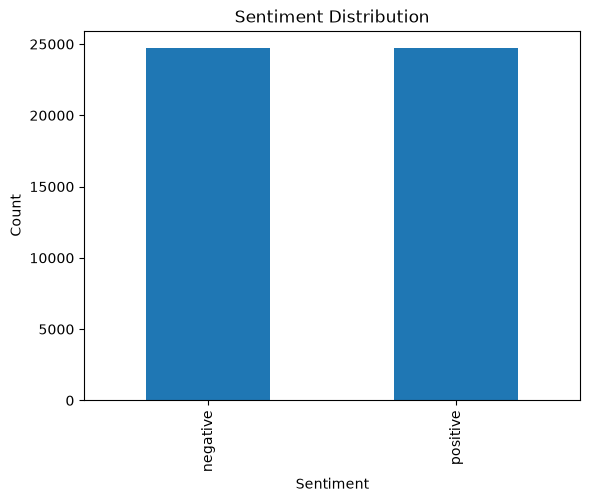

In [41]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [42]:
import nltk

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("All NLTK resources downloaded successfully.")

All NLTK resources downloaded successfully.


In [44]:
import nltk
import re

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required resources
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

df["Clean_Review"] = df["review"].apply(preprocess)

print(df.head())
print("\nColumns:")
print(df.columns)

                                              review sentiment  \
0  $25,000 Pyramid Clues: Deep Blue Sea. Tremors....  negative   
1  0.5/10. This movie has absolutely nothing good...  negative   
2  0*'s Christian Slater, Tara Reid, Stephen Dorf...  negative   
3  102 Dalmatians (2000, Dir. Kevin Lima) <br /><...  negative   
4  102 DALMATIANS [Walt Disney]: I wasn't a fan o...  negative   

                                        Clean_Review  
0  pyramid clue deep blue sea tremor slither eigh...  
1  movie absolutely nothing good acting among wor...  
2  christian slater tara reid stephen dorff frank...  
3  dalmatian dir kevin lima br br believed cured ...  
4  dalmatian walt disney wasnt fan previous insta...  

Columns:
Index(['review', 'sentiment', 'Clean_Review'], dtype='str')


In [45]:
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df["Clean_Review"])

y = df["sentiment"]

print("Shape of TF-IDF Matrix:", X.shape)

Shape of TF-IDF Matrix: (49396, 164360)


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (39516, 164360)
Testing Shape: (9880, 164360)


In [47]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [48]:
y_pred = model.predict(X_test)

print(y_pred[:10])

['positive' 'positive' 'negative' 'negative' 'negative' 'positive'
 'negative' 'positive' 'negative' 'negative']


In [49]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8639676113360324


In [50]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4385  549]
 [ 795 4151]]


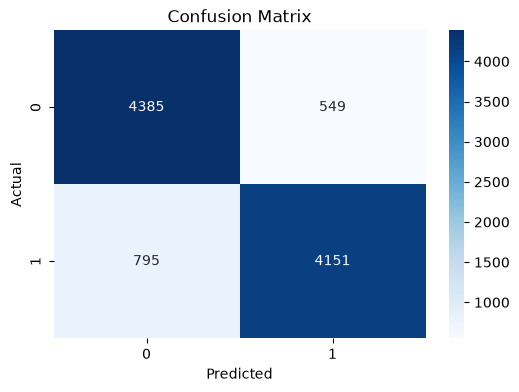

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.85      0.89      0.87      4934
    positive       0.88      0.84      0.86      4946

    accuracy                           0.86      9880
   macro avg       0.86      0.86      0.86      9880
weighted avg       0.86      0.86      0.86      9880



In [53]:
new_reviews = [
    "This movie is absolutely amazing and wonderful.",
    "I really enjoyed every moment of this film.",
    "Worst movie I have ever watched.",
    "The acting was terrible and boring.",
    "Excellent story with brilliant acting."
]

new_reviews_clean = [preprocess(review) for review in new_reviews]

new_reviews_vector = tfidf.transform(new_reviews_clean)

predictions = model.predict(new_reviews_vector)

for review, sentiment in zip(new_reviews, predictions):
    print("Review:", review)
    print("Prediction:", sentiment)
    print("-" * 50)

Review: This movie is absolutely amazing and wonderful.
Prediction: positive
--------------------------------------------------
Review: I really enjoyed every moment of this film.
Prediction: positive
--------------------------------------------------
Review: Worst movie I have ever watched.
Prediction: negative
--------------------------------------------------
Review: The acting was terrible and boring.
Prediction: negative
--------------------------------------------------
Review: Excellent story with brilliant acting.
Prediction: positive
--------------------------------------------------


In [54]:
print("=" * 60)
print("NATURAL LANGUAGE PROCESSING PROJECT COMPLETED")
print("=" * 60)

print("Dataset Used : IMDb Movie Reviews")
print("Dataset Size :", len(df))
print("Algorithm : Multinomial Naive Bayes")
print("Feature Extraction : TF-IDF")
print("Accuracy :", round(accuracy * 100, 2), "%")

print("\nProject Goals Achieved Successfully")

print("✔ Text Cleaning")
print("✔ Tokenization")
print("✔ Stopword Removal")
print("✔ Lemmatization")
print("✔ TF-IDF Vectorization")
print("✔ Model Training")
print("✔ Model Evaluation")
print("✔ Sentiment Prediction")

NATURAL LANGUAGE PROCESSING PROJECT COMPLETED
Dataset Used : IMDb Movie Reviews
Dataset Size : 49396
Algorithm : Multinomial Naive Bayes
Feature Extraction : TF-IDF
Accuracy : 86.4 %

Project Goals Achieved Successfully
✔ Text Cleaning
✔ Tokenization
✔ Stopword Removal
✔ Lemmatization
✔ TF-IDF Vectorization
✔ Model Training
✔ Model Evaluation
✔ Sentiment Prediction


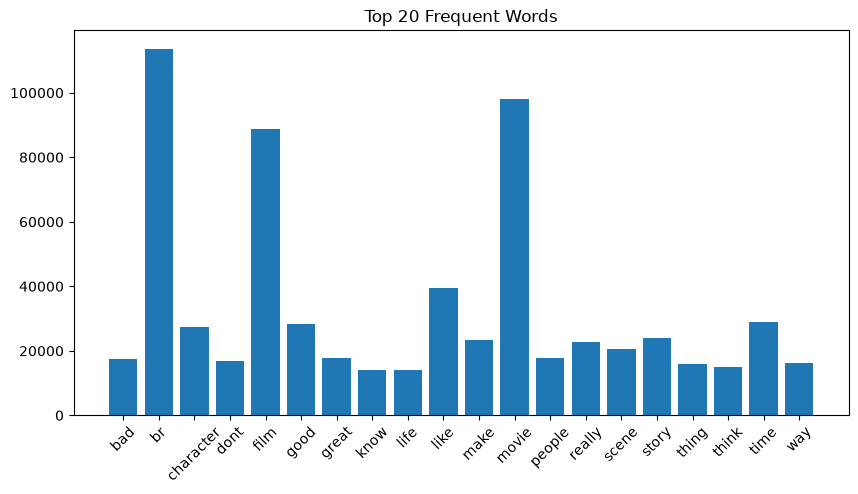

In [55]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

cv = CountVectorizer(stop_words='english', max_features=20)

X_words = cv.fit_transform(df["Clean_Review"])

word_counts = X_words.toarray().sum(axis=0)

words = cv.get_feature_names_out()

plt.figure(figsize=(10,5))

plt.bar(words, word_counts)

plt.xticks(rotation=45)

plt.title("Top 20 Frequent Words")

plt.show()

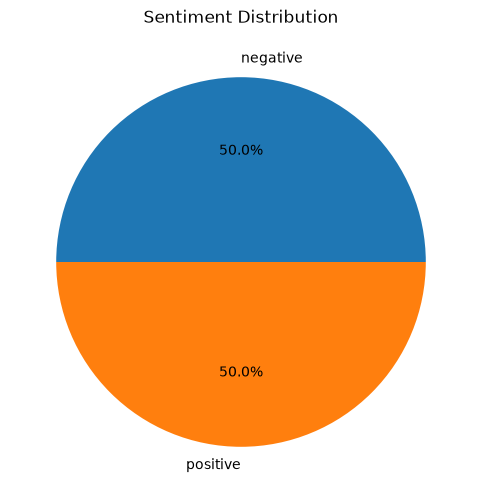

In [56]:
df["sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")

plt.title("Sentiment Distribution")

plt.show()